<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/07_lognormal_varying_intercept_slope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 7 — Hierarchical lognormal regression

Notebook 5 let participants differ in both their baseline reaction time and their response to sleep deprivation, using a Gaussian likelihood. Notebook 6 replaced the Gaussian likelihood with a lognormal one, which keeps reaction times positive and makes the daily effect multiplicative; but with only population-level parameters, whole participants sat systematically above or below its predictive bands.

This notebook combines the two: Notebook 5's varying intercepts and slopes, with Notebook 6's lognormal likelihood and log-scale priors. Both pieces are already familiar, so the full model is supplied up front. The task is to **read the combined model**: what each parameter means now that the hierarchy lives on the log scale, how the familiar workflow checks it, and what the fitted hierarchy says about sleep deprivation.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

assert participant_idx.min() == 0
assert participant_idx.max() == len(participants) - 1
assert np.array_equal(
    np.asarray(participants)[participant_idx],
    sleep["Subject"].to_numpy(),
)

print(f"{len(participants)} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

The participant plotting helper from the previous notebooks is supplied. It can optionally restrict plots to selected participants using the standard ArviZ `coords` argument.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")
    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Read the hierarchical lognormal model

### 1.1 The model

The full model is supplied:

$$
y_i \sim \operatorname{LogNormal}(\mu_{y,i}, sd_y)
$$

$$
\mu_{y,i}
=
b_{0,s[i]}
+
b_{1,s[i]}\,\mathrm{days}_i
$$

$$
b_{0,s}
\sim
\operatorname{Normal}(\mu_{b0}, sd_{b0})
$$

$$
b_{1,s}
\sim
\operatorname{Normal}(\mu_{b1}, sd_{b1}).
$$

Here $s[i]$ identifies the participant who produced observation $i$. The mean structure is Notebook 5's and the likelihood is Notebook 6's. Equivalently, $\log y_i \sim \operatorname{Normal}(\mu_{y,i}, sd_y)$: Notebook 5's varying-intercept, varying-slope regression now describes **log** reaction time.

As in Notebook 5, the intercept and slope hierarchies are independent, so the model does not estimate whether participants' baselines and sleep-deprivation effects are correlated.

### 1.2 The complete PyMC implementation

The hierarchy has the same form as in Notebook 5. The priors for the population centers `mu_b0` and `mu_b1` are Notebook 6's priors for `b0` and `b1`, and `sd_y` keeps Notebook 6's residual prior. The between-participant scales `sd_b0` and `sd_b1` have new log-scale priors, examined in Section 2. As in Notebook 6, `mean_rt` is the expected reaction time in milliseconds.

In [5]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

# Hyperprior constants for the intercept hierarchy (log reaction time).
# The population center reuses Notebook 6's prior for b0.
mu_mu_b0 = 5
sd_mu_b0 = 0.55
sd_sd_b0 = 1 / 6

# Hyperprior constants for the slope hierarchy (change in log reaction time per day).
# The population center reuses Notebook 6's prior for b1.
mu_mu_b1 = 0
sd_mu_b1 = 0.2
sd_sd_b1 = 0.05

# Prior constant for residual variation (log scale), reused from Notebook 6
mu_sd_y = 1 / 3

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    # Varying intercepts
    mu_b0 = pm.Normal("mu_b0", mu=mu_mu_b0, sigma=sd_mu_b0)
    sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)
    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0, dims="participant")

    # Varying slopes
    mu_b1 = pm.Normal("mu_b1", mu=mu_mu_b1, sigma=sd_mu_b1)
    sd_b1 = pm.Exponential("sd_b1", scale=sd_sd_b1)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1, dims="participant")

    # Likelihood
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)
    mu_y = pm.Deterministic(
        "mu_y",
        b0[pidx] + b1[pidx] * days,
        dims="obs_id",
    )

    # Expected reaction time in milliseconds
    mean_rt = pm.Deterministic(
        "mean_rt",
        pm.math.exp(mu_y + sd_y**2 / 2),
        dims="obs_id",
    )

    y = pm.LogNormal(
        "y",
        mu=mu_y,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

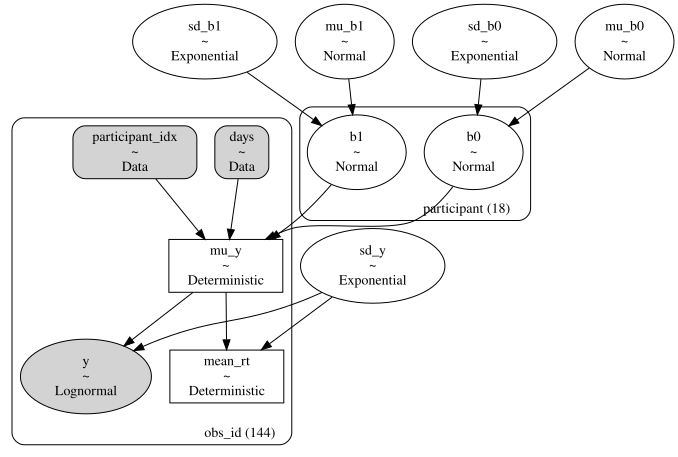

In [6]:
pm.model_to_graphviz(model)

### 1.3 Which quantities vary by participant?

Which model variables contain one value for every participant?

`b0` and `b1`. The observation-level quantities `mu_y` and `mean_rt` also differ between participants, because each observation uses its own participant's `b0` and `b1`, selected by `pidx`.

### 1.4 Which parameter is the population-average daily effect of sleep deprivation, and how does it act on reaction time?

`mu_b1`, the center of the population distribution of participant slopes. Like `b1` in Notebook 6, it is on the log scale, so it acts **multiplicatively**: for a participant whose slope equals `mu_b1`, each day multiplies the median reaction time by $e^{\mu_{b1}}$. For small values, `mu_b1` is approximately the proportional change per day.

### 1.5 Which parameters describe the population distributions of intercepts and slopes?

Which give the centers, and which give the between-participant scales? What does a difference of one `sd_b0` mean for reaction time in milliseconds?

`mu_b0` and `mu_b1` are the centers, and `sd_b0` and `sd_b1` are the between-participant standard deviations, of the intercepts and the slopes respectively.

Because they act on the log scale, these differences are **proportional**, not fixed numbers of milliseconds. A participant one `sd_b0` above the center has a baseline median reaction time $e^{sd_{b0}}$ times the center's, and a participant one `sd_b1` above the center has an extra factor of $e^{sd_{b1}}$ multiplying their median reaction time each day.

### 1.6 What does `sd_y` describe in this model?

`sd_y` keeps Notebook 6's prior, an Exponential distribution with mean 1/3. Would you expect its value to be smaller or larger than in Notebook 6, and why?

It is the standard deviation of a participant's log reaction time around **that participant's own** trajectory, that is, day-to-day variation within a participant. In Notebook 6, with a single population trajectory, `sd_y` also had to absorb persistent differences between participants, so here we should expect it to be **smaller**.

Notebook 6's prior is therefore generous for this narrower role. That is acceptable: all 144 observations inform `sd_y`, so the data should dominate its posterior (Section 6 checks this).

### 1.7 What does `mean_rt` represent, and how does it differ from `mu_y`?

`mu_y` is the mean of **log** reaction time for one participant on one day, so $e^{\mu_y}$ is that participant's median reaction time on that day. `mean_rt`, equal to $\exp(\mu_y + sd_y^2/2)$, is the corresponding expected reaction time in milliseconds, slightly above the median because the lognormal distribution is right-skewed. Unlike in Notebook 6, both now differ between participants as well as across days.

## 2. Check the prior implications

### 2.1 Criteria

The prior predictions should meet the criteria established in Notebook 1: predicted reaction times should not routinely be physically impossible, reaction times near baseline should mostly occupy a broadly plausible range, and the model should allow substantial change across the seven days without routinely generating absurd trajectories.

As in Notebooks 4 and 5, the hierarchy priors should also allow meaningful differences among participants' baselines and sleep-deprivation effects without making enormous differences routine. On the log scale these differences are proportional (Question 1.5).

### 2.2 Draw from the prior and plot the parameter priors.

Sampling: [b0, b1, mu_b0, mu_b1, sd_b0, sd_b1, sd_y, y]


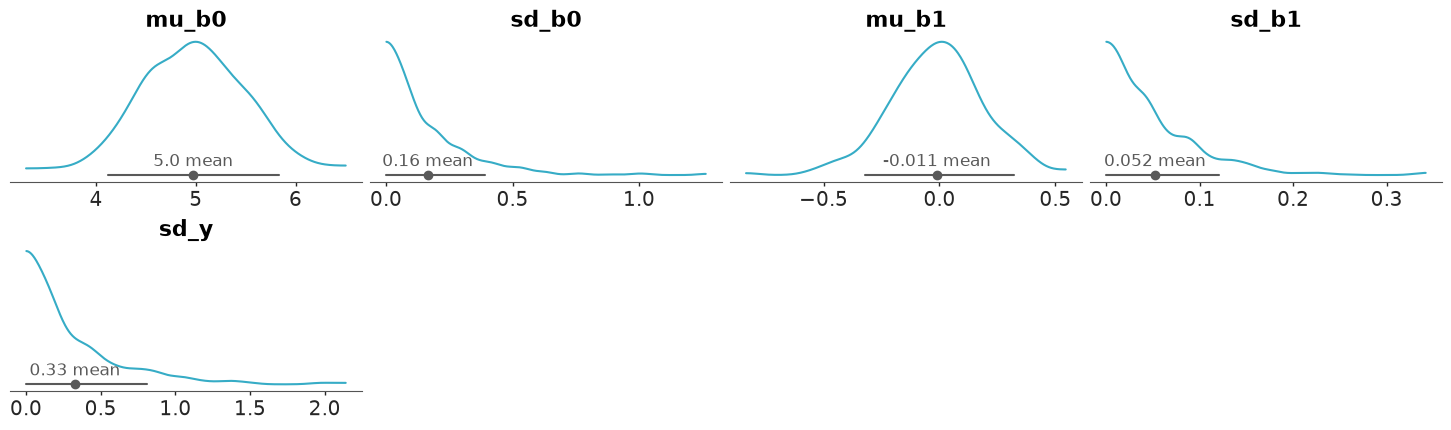

In [7]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y", "y"],
        random_seed=RANDOM_SEED,
    )

azp.plot_dist(
    prior,
    group="prior",
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 2.3 Are the hierarchy priors reasonable?

Read `sd_b0` and `sd_b1` multiplicatively. Do they allow meaningful differences between participants without making enormous differences routine? Remember that a difference in daily effect accumulates over the seven days.

Yes, as deliberately permissive priors. `sd_b0` is mostly below about 0.4, so one standard deviation of participant baselines typically corresponds to a 10–20% difference in median reaction time, and rarely to more than a factor of about 1.5.

`sd_b1` is mostly below about 0.11. At its prior mean, 0.05, a participant one standard deviation above the center slows about 5% per day more than the center, which compounds to a factor of $e^{7 \times 0.05} \approx 1.4$ over seven days; near the upper end of the prior the factor is about 2. This is why the slope-variation prior is much tighter than the intercept-variation prior: a difference in daily effect is multiplied by the number of days.

The remaining priors, on `mu_b0`, `mu_b1`, and `sd_y`, are Notebook 6's; the prior predictive check shows what they imply together.

### 2.4 Plot the prior predictive reaction times.

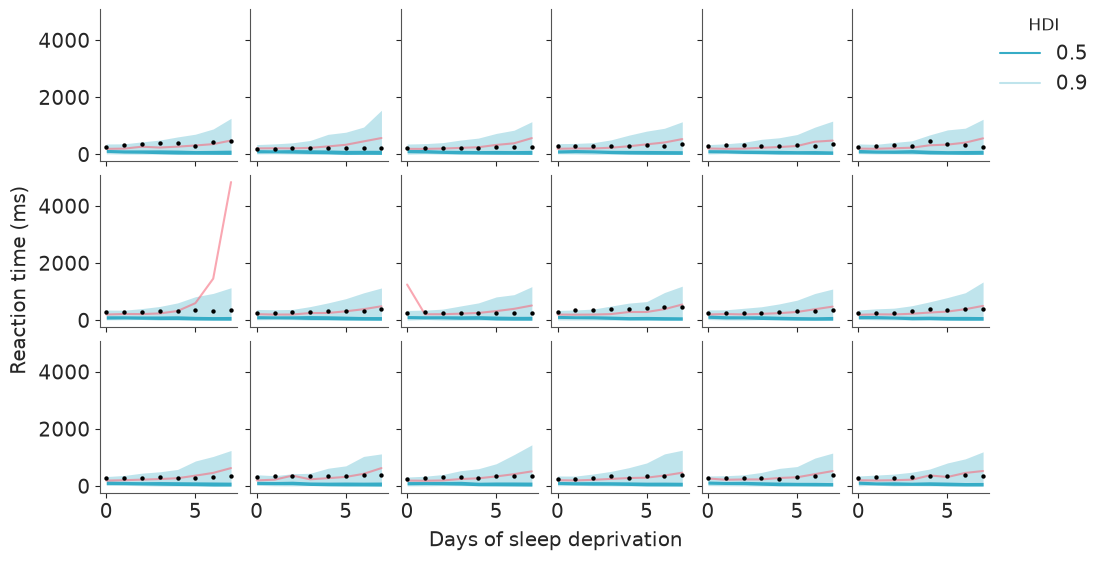

In [8]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.5 Do these prior predictions meet the criteria established in Notebook 1?

Judge support, baseline scale, and changes across days.

Only partly, and no better than in Notebook 6. Every prediction is a positive reaction time, and at baseline the 90% bands span roughly 20–350 ms. But the 50% bands lie below about 200 ms on every day, below every observed reaction time: the prior's most probable reaction times are implausibly fast, because the baseline is centered, as in Notebook 6, on a median of $e^{5} \approx 150$ ms. Daily effects act multiplicatively, so their uncertainty compounds across days: by day 7 the 50% band reaches almost zero and the 90% band extends beyond a second. A couple of panels also show the mean line spike sharply upward late in the week: a rare, large sampled slope difference compounding over seven days — exactly the risk Question 2.3 warned about, now visible for a specific simulated participant rather than only in the hyperparameter priors.

These are Notebook 6's deliberately broad teaching priors, carried over so that the hierarchy is the only new ingredient. We proceed, and Section 6 checks whether they influence the posterior.

### 2.6 Why do most panels look similar, but one or two show an extreme spike?

Every participant has their own `b0` and `b1`, drawn from the same population priors.

Before seeing the data, participants are **exchangeable**: every participant's `b0` and `b1` are drawn from the same population distribution, so every panel is an independent draw from that same prior predictive distribution. Most panels look similar because that shared distribution is fairly narrow through midweek. The one or two panels with a sharp late-week spike are not a different kind of participant in any prior sense — they are the same distribution's rare, large sampled slope differences, made visible because there are 18 independent draws to look at.

The prior allows participants to differ, through `sd_b0` and `sd_b1`, but it cannot know in advance which participant will be fast or slow, or strongly or weakly affected. That is why between-participant differences were judged from the hyperparameter priors in Question 2.3, not from these panels.

## 3. Fit and diagnose the hierarchy

### 3.1 Sample from the posterior.

In [9]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, mu_b1, sd_b1, b1, sd_y]


/tmp/claude-0/-home-user-BayesShortCourse/454cacc3-077e-57ca-973e-ce021f0d1966/scratchpad/nbenv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Output()

/tmp/claude-0/-home-user-BayesShortCourse/454cacc3-077e-57ca-973e-ce021f0d1966/scratchpad/nbenv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 5 seconds.


### 3.2 Check population-level diagnostics.

In [10]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,5.59,0.03,5.54,5.64,5557.45,3388.24,1.0,0.0,0.0
sd_b0,0.13,0.03,0.08,0.16,4903.33,3076.17,1.0,0.0,0.0
mu_b1,0.04,0.01,0.02,0.05,4696.39,3372.05,1.0,0.0,0.0
sd_b1,0.02,0.01,0.01,0.03,3034.31,2985.44,1.0,0.0,0.0
sd_y,0.08,0.01,0.07,0.09,4235.92,3464.67,1.0,0.0,0.0


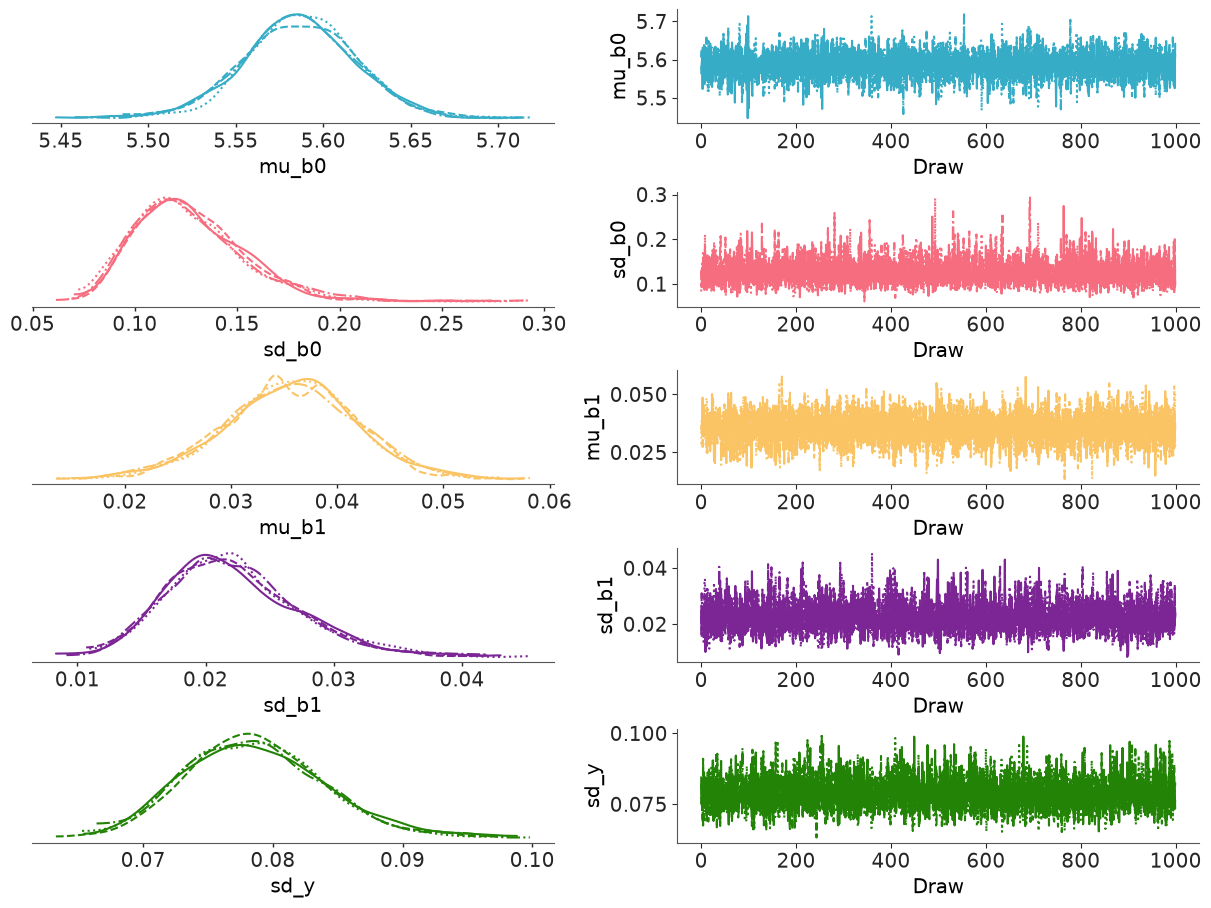

In [11]:
azp.plot_trace_dist(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y"],
);

### 3.3 Do the population-level parameters meet the diagnostic criteria?

Use the criteria established in Notebook 1: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces.

Yes. There are no divergences, every population-level R-hat is 1.00, the bulk and tail ESS values are all in the thousands, and the traces show well-mixed chains. As in Notebook 5, the centered hierarchy samples reliably with the default settings.

### 3.4 Screen all participants, then inspect a representative subset.

In [12]:
participant_diagnostics = azs.summary(
    idata,
    var_names=["b0", "b1"],
    kind="diagnostics",
    round_to=2,
)

display(pd.DataFrame(
    {
        "value": [
            participant_diagnostics["r_hat"].max(),
            participant_diagnostics["ess_bulk"].min(),
            participant_diagnostics["ess_tail"].min(),
        ]
    },
    index=["largest R-hat", "smallest bulk ESS", "smallest tail ESS"],
))

diagnostic_participants = [
    participants[0],
    participants[len(participants) // 2],
    participants[-1],
]
diagnostic_coords = {"participant": diagnostic_participants}

azs.summary(
    idata,
    var_names=["b0", "b1"],
    coords=diagnostic_coords,
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

,value
largest R-hat,1.00
smallest bulk ESS,4146.45
smallest tail ESS,2601.93


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[308],5.68,0.04,5.60,5.75,5298.53,3443.55,1.0,0.0,0.0
b0[337],5.75,0.05,5.67,5.82,5326.96,3060.93,1.0,0.0,0.0
b0[372],5.66,0.04,5.59,5.74,6268.01,3341.15,1.0,0.0,0.0
b1[308],0.06,0.01,0.04,0.07,4875.68,2601.93,1.0,0.0,0.0
b1[337],0.06,0.01,0.04,0.08,5145.42,3322.53,1.0,0.0,0.0
b1[372],0.04,0.01,0.02,0.05,6332.19,3229.69,1.0,0.0,0.0


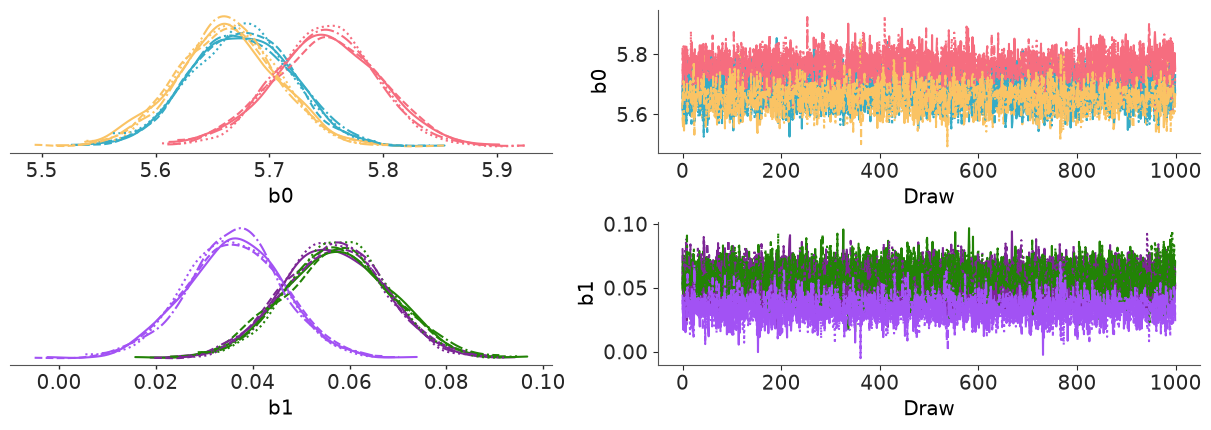

In [13]:
azp.plot_trace_dist(
    idata,
    var_names=["b0", "b1"],
    coords=diagnostic_coords,
);

### 3.5 Do the participant-level parameters meet the same criteria?

Yes. The all-participant screen shows a largest R-hat of 1.00 and smallest bulk and tail ESS values in the thousands, and the intercept and slope traces for participants 308, 337, and 372 mix well.

## 4. Examine the fitted hierarchy

### 4.1 Plot the posterior distribution of the population-average daily effect.

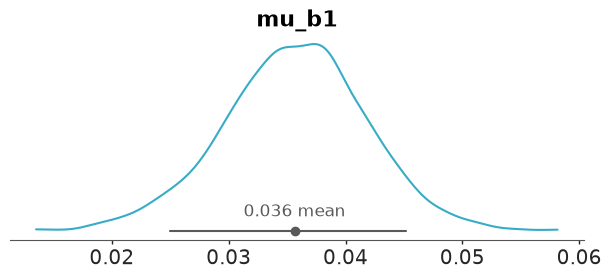

In [14]:
azp.plot_dist(
    idata,
    var_names=["mu_b1"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.2 What range of population-average daily effects is credible?

Use the 90% HDI from the posterior summary in Question 3.2, and express it as a percentage change per day.

The 90% HDI for `mu_b1` is approximately **0.02–0.05**: at the population center, each day of sleep deprivation slows reaction times by about **2–5%**. This is close to the single population slope of Notebook 6, but it now describes the center of a distribution of participant effects rather than one effect shared by everyone.

### 4.3 Plot the posterior distribution of the parameter that controls participant-to-participant variation in daily effects.

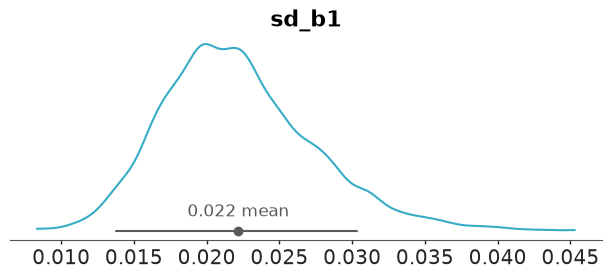

In [15]:
azp.plot_dist(
    idata,
    var_names=["sd_b1"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.4 What range of slope-variation scales is credible?

Use the 90% HDI for `sd_b1`, and express it in percentage points per day.

The 90% HDI for `sd_b1` is approximately **0.01–0.03**: participants' daily effects vary around the population center with a standard deviation of about **1–3 percentage points per day**. That is large relative to a center of 2–5% per day.

### 4.5 Plot the participant-specific daily effects.

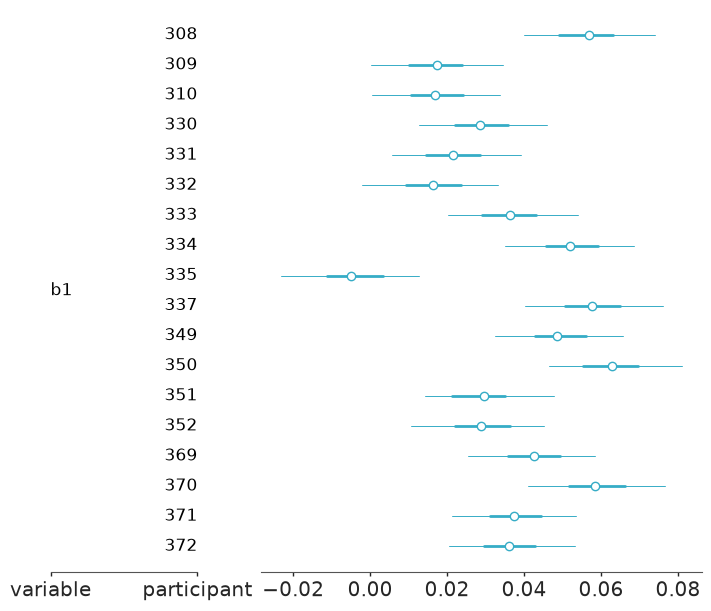

In [16]:
azp.plot_forest(
    idata,
    var_names=["b1"],
    combined=True,
    ci_probs=(0.50, 0.90),
    ci_kind="hdi",
    figure_kwargs={"figsize": (7, 6)},
);

### 4.6 Does the fitted model support meaningful heterogeneity in sleep-deprivation effects?

Base the answer on the participant intervals and the posterior for `sd_b1`.

Yes. The posterior for `sd_b1` is clearly above zero, and the participant intervals occupy visibly different regions: participant 335's daily effect is close to zero, while participants such as 308, 337, 350, and 370 slow by roughly 6% per day.

### 4.7 How does the fitted `sd_y` compare with Notebook 6's?

Notebook 6's fitted residual scale was about 0.17. Use the posterior summary in Question 3.2.

The fitted `sd_y` is about **0.08** (90% HDI roughly 0.07–0.09), about half of Notebook 6's value, as Question 1.6 anticipated. In Notebook 6, persistent differences between participants had to be absorbed as residual noise; here `b0` and `b1` carry them, and `sd_y` describes only day-to-day variation: one residual standard deviation multiplies or divides a participant's median reaction time by about $e^{0.08} \approx 1.08$.

With `sd_y` this small, `mean_rt` is only about 0.3% above the median $e^{\mu_y}$.

## 5. Predictive consequences

### 5.1 Plot each participant's posterior expected reaction time.

Use `plot_participants` with the variable that gives the expected reaction time in milliseconds.

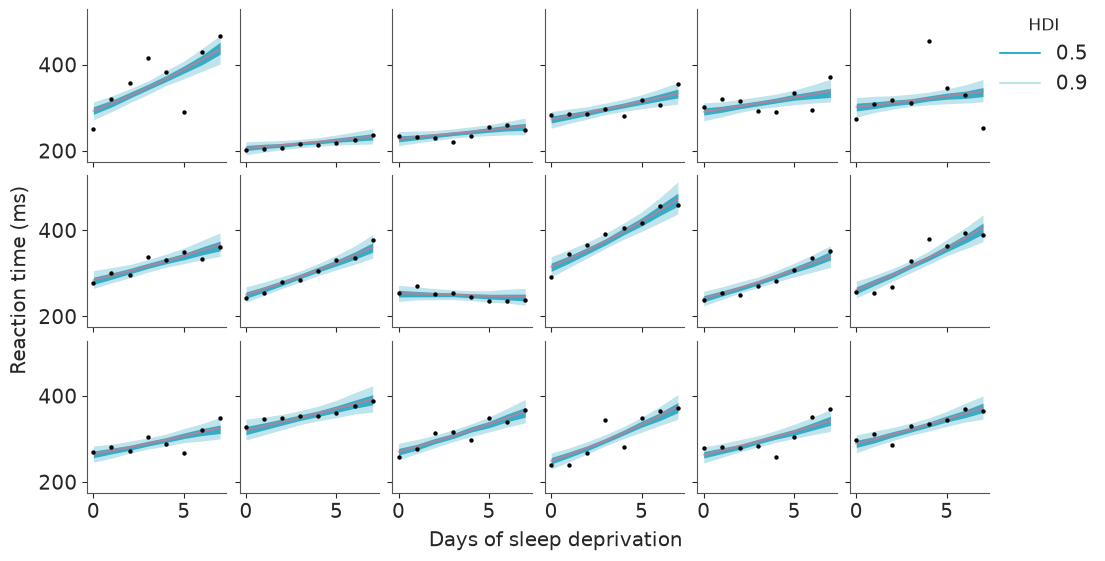

In [17]:
plot_participants(idata, "posterior", "mean_rt")
plt.show()

### 5.2 What uncertainty do these bands represent?

Is it uncertainty about each participant's expected reaction time or uncertainty about future reaction times?

It is uncertainty about each **participant's expected reaction time** `mean_rt` on each day. It does not include day-to-day variation of individual reaction times around that expectation, which is why the observations scatter more widely than the bands. Unlike the single population curve of Notebook 6, every participant now has their own expected trajectory, with its own level and rate of change.

### 5.3 Generate and plot posterior predictive reaction times.

Generate replicated values of `y` from the fitted model, add them to `idata`, and compare them with the observations using `plot_participants`.

Sampling: [y]


Output()

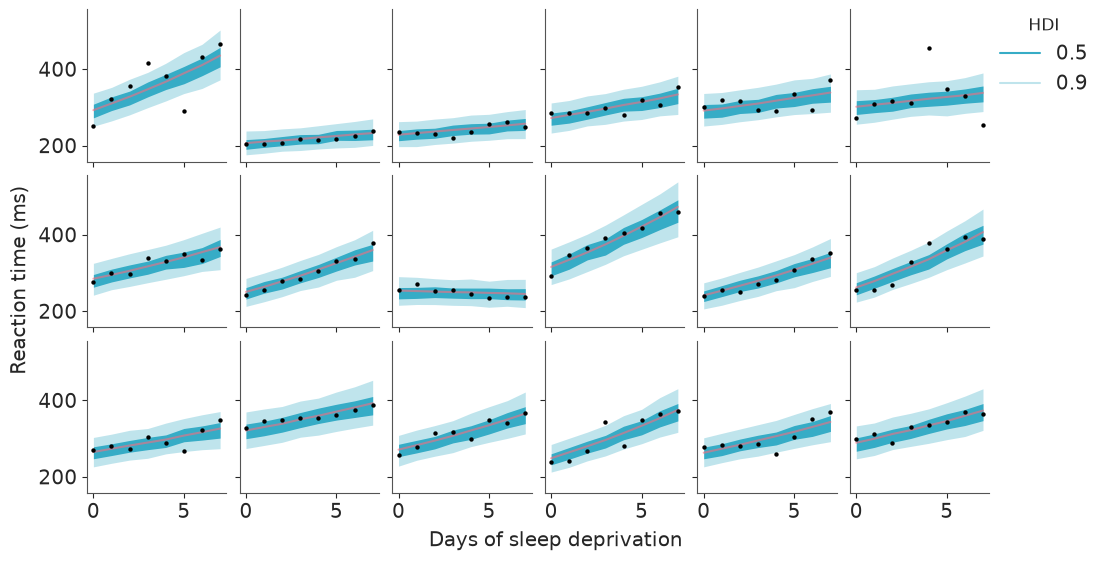

In [18]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 5.4 What is added when we move from `mean_rt` to posterior predictive `y`?

Residual day-to-day variation, controlled by `sd_y`. It is multiplicative, so in milliseconds the predictive bands are wider where a participant's reaction times are longer.

### 5.5 Does the model reproduce the participant-level data?

Apply the posterior predictive criteria from Notebook 1: participants' overall levels, changes across days, and residual variation, emphasizing discrepancies that persist across a participant's observations. Also check positivity, and compare with Notebook 6's participant-level check.

Largely, yes, and much better than Notebook 6. Every replicated reaction time is positive, and each participant's bands follow that participant's own level and rate of change, so no participant sits systematically above or below them.

The remaining misses are isolated observations, concentrated in a few participants whose reaction times jump from day to day, such as 308 and 332. For steadier participants, such as 309, the observations sit well inside the bands: all participants share one residual scale `sd_y`.

### 5.6 What would indicate adequate fit in an ECDF check?

The participant panels check conditional trajectories. Pooling all observations asks a different question: does the model reproduce the overall distribution of reaction times?

As in Notebooks 5 and 6, the observed ECDF should be broadly consistent with the posterior-predictive ECDFs across the whole distribution, without a persistent systematic displacement, particularly in the tails.

### 5.7 Plot the observed and posterior-predictive ECDFs.

Use `azp.plot_ppc_dist` with `kind="ecdf"`.

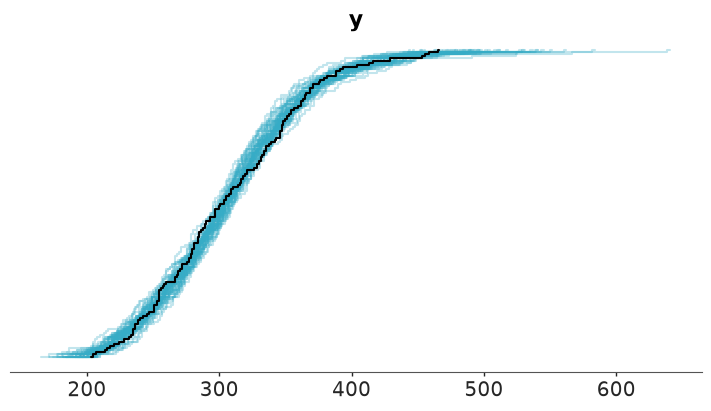

In [19]:
azp.plot_ppc_dist(
    idata,
    var_names=["y"],
    kind="ecdf",
    figure_kwargs={"figsize": (7, 4)},
);

### 5.8 Does the model reproduce the overall distribution, and how does this compare with Notebook 6?

Broadly, yes. The observed ECDF lies within the spread of the posterior-predictive ECDFs across the whole distribution, with no persistent displacement in either tail.

Notebook 6's population-level lognormal model passed this check too, so the pooled ECDF does not distinguish the two models: it ignores which participant produced which reaction time. The difference between them is in the participant-level check (Question 5.5), where this model reproduces each participant's level and rate of change and Notebook 6's model could not.

## 6. Sensitivity of the hierarchical scales

### 6.1 Why check prior sensitivity here, and which priors should be power-scaled?

The prior predictions in Section 2 were only partly plausible, and the between-participant scales `sd_b0` and `sd_b1` are informed by only 18 participants rather than by all 144 observations. Power-scaling sensitivity, introduced in Notebook 1, asks whether slightly strengthening or weakening the priors would move the posterior substantially.

In a hierarchical model, not every prior density is a prior assumption we chose. The distributions $b_{0,s} \sim \operatorname{Normal}(\mu_{b0}, sd_{b0})$ and $b_{1,s} \sim \operatorname{Normal}(\mu_{b1}, sd_{b1})$ are the population model itself: they are how the participants' data inform `mu_b0`, `sd_b0`, `mu_b1`, and `sd_b1`. Power-scaling them would change that structure, and the diagnostic would then flag the hyperparameters for reasons unrelated to the priors we chose. We therefore power-scale only the top-level priors, on `mu_b0`, `sd_b0`, `mu_b1`, `sd_b1`, and `sd_y`, using the `prior_var_names` argument of `azs.psense_summary`.

### 6.2 Prepare the information required for power-scaling.

The bookkeeping code is supplied.

In [20]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(
        idata,
        model=model,
        kind="prior",
        extend_inferencedata=True,
    )

Output()

Output()

### 6.3 Calculate prior sensitivity.

Use `azs.psense_summary` for `mu_b0`, `sd_b0`, `mu_b1`, `sd_b1`, and `sd_y`, power-scaling only their priors with `prior_var_names`.

In [21]:
top_level = ["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y"]

azs.psense_summary(
    idata,
    var_names=top_level,
    prior_var_names=top_level,
)

,prior,likelihood,diagnosis
mu_b0,0.011,0.014,✓
sd_b0,0.034,0.064,✓
mu_b1,0.003,0.020,✓
sd_b1,0.019,0.161,✓
sd_y,0.001,0.536,✓


### 6.4 Are the conclusions sensitive to the priors?

Recall that ArviZ uses 0.05 as a screening threshold for prior sensitivity. Does the `diagnosis` column flag any parameter?

No. All five prior sensitivities are below 0.05, and the `diagnosis` column flags none of them. The largest is for `sd_b0` (about 0.03), which is informed by only 18 participant baselines; even there, the broad priors of Section 2 have little influence on the posterior.

## 7. Summary

### 7.1 What has this notebook shown?

Summarize what combining the hierarchy with the lognormal likelihood showed about the meaning of the parameters, the priors, the fitted hierarchy, the predictive checks, and prior sensitivity.

- **Parameters.** Combining Notebook 5's hierarchy with Notebook 6's likelihood puts the whole mean structure on the log scale. Participants' baselines and daily effects differ proportionally rather than by fixed numbers of milliseconds, and `mean_rt` turns each participant's `mu_y` into an expected reaction time in milliseconds.
- **Priors.** Notebook 6's broad log-scale priors, carried over for the population centers and the residual scale, still give prior predictions that are always positive but centered on implausibly fast reaction times and very permissive late in the week. Because a difference in daily effect compounds over the week, the slope-variation prior is much tighter than the intercept-variation prior. Before seeing data, participants are exchangeable, so between-participant variation was judged from the `sd_b0` and `sd_b1` priors rather than from the panels.
- **Fitted hierarchy.** The centered parameterization sampled cleanly with the default settings. At the population center, reaction times slow by about 2–5% per day, and the daily effect varies substantially between participants, from near zero to about 6% per day. The residual scale `sd_y` is about half of Notebook 6's, because persistent differences between participants are now carried by `b0` and `b1` rather than by residual noise.
- **Predictive checks.** The participant-level posterior predictive check no longer shows Notebook 6's systematic misfit: each participant's level and rate of change are reproduced, and the remaining misses are isolated observations concentrated in a few participants whose reaction times vary most from day to day. The pooled ECDF is broadly consistent with the data, as it was in Notebook 6.
- **Sensitivity.** Power-scaling the top-level priors flags none of the parameters, so the broad priors do not drive these conclusions.